# Parameter recovery

Simulate from the model at known parameters, fit it back, and see what survives. Each section adds one piece of the specification, so a failure names the piece that caused it.

In [40]:
# Reload the sidecar on every cell, and nothing else. A pytensor checkout that moves under a
# blanket autoreload re-imports its rewrite modules, which register themselves a second time and
# leave the graph database corrupt; naming one module keeps that out of reach.
%load_ext autoreload
%autoreload 1
%aimport svgp_support

# Double, unlike the regional fits. These lattices are small enough to run on the CPU, and a
# recovery exercise that misses by a hair should not leave precision as one of the explanations.
import pytensor

pytensor.config.floatX = "float64"

import time

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import ptgp
import pytensor.tensor as pt
import shapely

from ptgp.inducing import compute_inducing_diagnostics
from ptgp.kernels import Matern32

from climate_risk.models.aggregation import Aggregation
from climate_risk.plotting import configure_plot_style
from svgp_support import annealed_adam, build_model_2, fit_minibatch, select_inducing

FLOATX = pytensor.config.floatX
COMPILE_MODE = "FAST_RUN"

# The column order build_model_2 reads the feature matrix by.
YEAR, TO_RIVER, TO_COAST, RIVER_FLOW = 0, 1, 2, 3
N_KERNEL_DIMS = 4

pz.rcParams["plots.show_plot"] = False
configure_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## A lattice small enough to fit many times

Recovery needs replicates, so the lattice is sized for a fit in seconds rather than the sixteen minutes the regional fit takes.

In [44]:
SEED = 20260827
N_ATOMS = 300
N_YEARS = 20
N_COUNTRIES = 3
DOMAIN = 10.0
KM_PER_UNIT = 60.0
CROWDING_SCALE = 2.0
CROWDING_TO_DENSITY = 12.0

rng = np.random.default_rng(SEED)

centers = rng.uniform(0.0, DOMAIN, size=(4, 2))


def crowding_at(x, y):
    """How built up a place is, as a few broad clusters over the domain."""
    distance = (np.asarray(x)[..., None] - centers[:, 0]) ** 2 + (np.asarray(y)[..., None] - centers[:, 1]) ** 2

    return np.exp(-0.5 * distance / CROWDING_SCALE**2).sum(axis=-1)


# Atoms drawn densely where the people are, which is how administrative units are actually cut: a
# city is many small units and the countryside is few large ones. Area then falls out of the
# tessellation and anti-correlates with population the way it does in GADM, which is the structure
# that cancelled the signal in the regional fit.
proposals = rng.uniform(0.0, DOMAIN, size=(40 * N_ATOMS, 2))
density = 1.0 + CROWDING_TO_DENSITY * crowding_at(proposals[:, 0], proposals[:, 1])
kept = rng.random(len(proposals)) < density / density.max()
atom_x, atom_y = proposals[kept][:N_ATOMS].T

extent = shapely.box(0.0, 0.0, DOMAIN, DOMAIN)
tessellation = shapely.voronoi_polygons(
    shapely.MultiPoint(np.column_stack([atom_x, atom_y])), extend_to=extent, ordered=True
)
atom_cells = gpd.GeoSeries(list(tessellation.geoms)).intersection(extent)
atom_area = atom_cells.area.to_numpy() * KM_PER_UNIT**2

# A river meandering down the domain, a coast along the western edge, and discharge growing
# downstream. Each atom's covariates are its distance to those, so they are smooth in space.
river_x = 5.0 + 2.0 * np.sin(2 * np.pi * atom_y / DOMAIN)
to_river = np.abs(atom_x - river_x)
to_coast = atom_x.copy()
river_flow = np.log1p(atom_y) + rng.normal(0.0, 0.1, N_ATOMS)

# Countries as their own partition, not bands along an axis. Bands in x leave the country
# indicators explaining almost all of distance to coast, and the offsets and the coast surface then
# fit the same thing and neither is identified. These seeds were chosen to keep the countries
# balanced while holding that shared variance down; some remains, because a contiguous country and
# a smooth covariate cannot be made orthogonal, which is true of the real geography too.
COUNTRY_SEEDS = np.array([[4.73, 1.85], [1.88, 5.86], [1.84, 8.43]])
country_of_atom = np.argmin(
    (atom_x[:, None] - COUNTRY_SEEDS[:, 0]) ** 2 + (atom_y[:, None] - COUNTRY_SEEDS[:, 1]) ** 2, axis=1
)
country_borders = gpd.GeoSeries(
    [atom_cells[country_of_atom == country].union_all() for country in range(N_COUNTRIES)]
)

atom_people = atom_area * np.exp(np.log(50.0) + 2.0 * crowding_at(atom_x, atom_y) + rng.normal(0.0, 0.3, N_ATOMS))


def standardized(values):
    """Centred and scaled to unit standard deviation, which is the axis the kernel expects."""
    return (values - values.mean()) / values.std()


log_people = np.log(atom_people)
years = np.arange(N_YEARS)
standardized_years = standardized(years)

atom_block = np.column_stack(
    [
        standardized(to_river),
        standardized(to_coast),
        standardized(river_flow),
        np.eye(N_COUNTRIES)[country_of_atom],
        standardized(log_people),
    ]
)
features = np.column_stack(
    [np.repeat(standardized_years, N_ATOMS), np.tile(atom_block, (N_YEARS, 1))]
).astype(FLOATX)

n_cells = N_ATOMS * N_YEARS
weights = np.tile(atom_area, N_YEARS).astype(FLOATX)
all_cells = np.arange(n_cells)

# The whole lattice in one row, which the objective subtracts once.
region = Aggregation(
    units=("region",), rows=np.zeros(n_cells, dtype=int), columns=all_cells, weights=weights, n_cells=n_cells
)


def events_at_cells(cells):
    """The observation operator for events seen at the atom-year they fell in, one row each."""
    event_rows = np.arange(len(cells))

    return Aggregation(
        units=tuple(str(row) for row in event_rows),
        rows=event_rows,
        columns=np.asarray(cells),
        weights=weights[cells],
        n_cells=n_cells,
    )


def plot_lattice(axis, values, *, title, cmap="magma", vmin=None, vmax=None, borders=True):
    """One year of an atom-level field, drawn over the units it is defined on."""
    frame = gpd.GeoDataFrame({"value": np.asarray(values)}, geometry=atom_cells)
    frame.plot(ax=axis, column="value", cmap=cmap, vmin=vmin, vmax=vmax, linewidth=0.0)
    if borders:
        country_borders.boundary.plot(ax=axis, color="0.25", linewidth=0.8)

    axis.set_aspect("equal")
    axis.set_axis_off()
    axis.set_title(title, loc="left")

    return axis.collections[0]


def country_share(values):
    """Share of a covariate's variance the country indicators explain, which is what confounds."""
    within = sum(
        ((values[country_of_atom == country] - values[country_of_atom == country].mean()) ** 2).sum()
        for country in range(N_COUNTRIES)
    )

    return 1.0 - within / (values.var() * len(values))


covariates_drawn = {
    "distance to river": to_river,
    "distance to coast": to_coast,
    "discharge": river_flow,
    "log people": log_people,
    "log km2": np.log(atom_area),
}

pd.DataFrame(
    {
        "explained by country": {name: country_share(values) for name, values in covariates_drawn.items()},
        "spread": {name: float(values.std()) for name, values in covariates_drawn.items()},
    }
).round(3)

,explained by country,spread
distance to river,0.02,1.67
distance to coast,0.28,2.59
discharge,0.42,0.40
log people,0.23,1.02
log km2,0.11,0.82


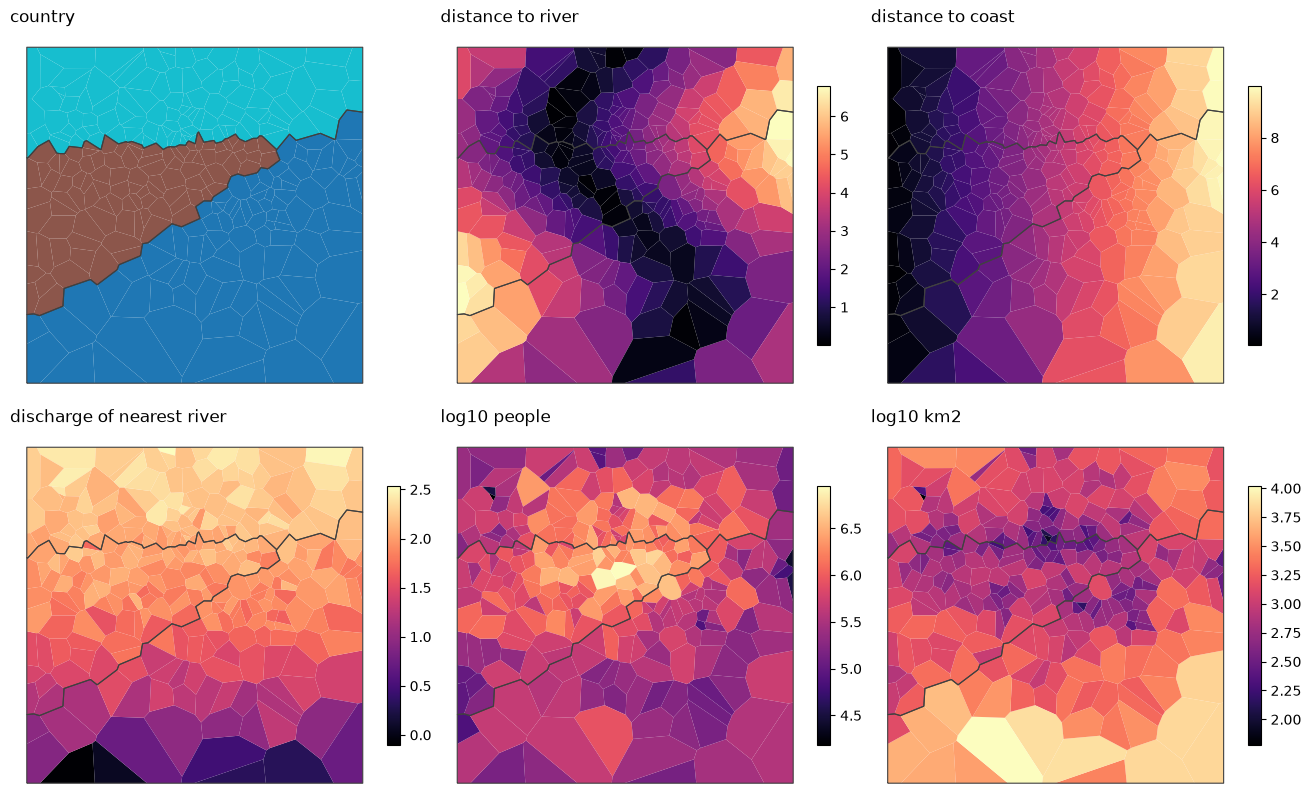

In [45]:
panels = [
    ("country", country_of_atom.astype(float), "tab10", False),
    ("distance to river", to_river, "magma", True),
    ("distance to coast", to_coast, "magma", True),
    ("discharge of nearest river", river_flow, "magma", True),
    ("log10 people", np.log10(atom_people), "magma", True),
    ("log10 km2", np.log10(atom_area), "magma", True),
]

figure, axes = plt.subplots(2, 3, figsize=(13, 8))

for axis, (title, values, cmap, with_bar) in zip(axes.ravel(), panels, strict=True):
    drawn = plot_lattice(axis, values, title=title, cmap=cmap)
    if with_bar:
        figure.colorbar(drawn, ax=axis, shrink=0.7, pad=0.02)

plt.show()

## 1. The parametric part alone

No GP. Known intercept, country offsets and population exponent, Poisson counts drawn at the atoms themselves. Recovering these three tests the likelihood, the area base measure and the exposure wiring with nothing else in the way.

In [46]:
TARGET_EVENTS = 1500
TRUE_COUNTRY_OFFSETS = np.array([-0.8, 0.1, 0.9])
TRUE_POPULATION_EXPONENT = 0.6

country_part = features[:, N_KERNEL_DIMS:-1] @ TRUE_COUNTRY_OFFSETS
population_part = TRUE_POPULATION_EXPONENT * features[:, -1]

# The intercept is solved for rather than picked, so the simulated record carries the same number
# of events as the real one and the exercise is not quietly run at an easier signal to noise.
TRUE_INTERCEPT = float(np.log(TARGET_EVENTS) - np.log((weights * np.exp(country_part + population_part)).sum()))

true_rate = weights * np.exp(TRUE_INTERCEPT + country_part + population_part)
counts_flat = rng.poisson(true_rate)
observations_1 = events_at_cells(np.repeat(all_cells, counts_flat))

pd.Series(
    {
        "true intercept": TRUE_INTERCEPT,
        "events drawn": float(observations_1.n_units),
        "atom-years with an event": float((counts_flat > 0).mean()),
        "busiest atom-year": float(counts_flat.max()),
        "expected events at an atom-year, median": float(np.median(true_rate)),
    },
    name="value",
).to_frame().round(4)

,value
true intercept,-8.75
events drawn,1502.00
atom-years with an event,0.19
busiest atom-year,7.00
"expected events at an atom-year, median",0.15


In [47]:
N_INDUCING = 150
ADAM_STEPS = 3000
COVARIATE_BOUNDS = (0.5, 5.0)
TEMPORAL_BOUNDS = (2.0 / years.std(), 20.0 / years.std())


def prior_kernel(covariate_ls=2.3, temporal_ls=None, amplitude=0.57):
    """The two Matern surfaces at plausible hyperparameters, for judging a set of inducing points."""
    temporal_ls = 9.2 / years.std() if temporal_ls is None else temporal_ls

    return amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([covariate_ls, covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )


inducing = select_inducing(features, N_INDUCING, prior_kernel())[:, :N_KERNEL_DIMS]

started = time.perf_counter()
svgp_1, result_1 = fit_minibatch(
    features,
    observations_1,
    weights,
    inducing,
    mode=COMPILE_MODE,
    n_steps=ADAM_STEPS,
    n_windows=256,
    batch_size=2000,
    optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=8e-3),
    model_fn=build_model_2,
    covariate_bounds=COVARIATE_BOUNDS,
    temporal_bounds=TEMPORAL_BOUNDS,
)
seconds_1 = time.perf_counter() - started
trained_1 = result_1.params

# An intercept alongside an indicator for every country is one parameter too many: adding a
# constant to the intercept and taking it off every offset leaves the rate unchanged. Only the
# level and the contrasts against the mean are identified, so those are what is compared.
fitted_offsets = np.asarray(trained_1["country_offsets"])
recovery_1 = pd.DataFrame(
    {
        "true": [
            TRUE_INTERCEPT + TRUE_COUNTRY_OFFSETS.mean(),
            *(TRUE_COUNTRY_OFFSETS - TRUE_COUNTRY_OFFSETS.mean()),
            TRUE_POPULATION_EXPONENT,
            0.0,
            0.0,
        ],
        "fitted": [
            float(trained_1["intercept"]) + fitted_offsets.mean(),
            *(fitted_offsets - fitted_offsets.mean()),
            float(trained_1["population_exponent"]),
            float(trained_1["hydro_amplitude"]),
            float(trained_1["coast_amplitude"]),
        ],
    },
    index=[
        "level",
        *(f"country {index} contrast" for index in range(N_COUNTRIES)),
        "population exponent",
        "hydro amplitude",
        "coast amplitude",
    ],
)
recovery_1["error"] = recovery_1["fitted"] - recovery_1["true"]
recovery_1.round(3)

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

,true,fitted,error
level,-8.68,-8.70,-0.02
country 0 contrast,-0.87,-0.83,0.04
country 1 contrast,0.03,0.01,-0.02
country 2 contrast,0.83,0.81,-0.02
population exponent,0.60,0.60,0.00
hydro amplitude,0.00,0.09,0.09
coast amplitude,0.00,0.08,0.08


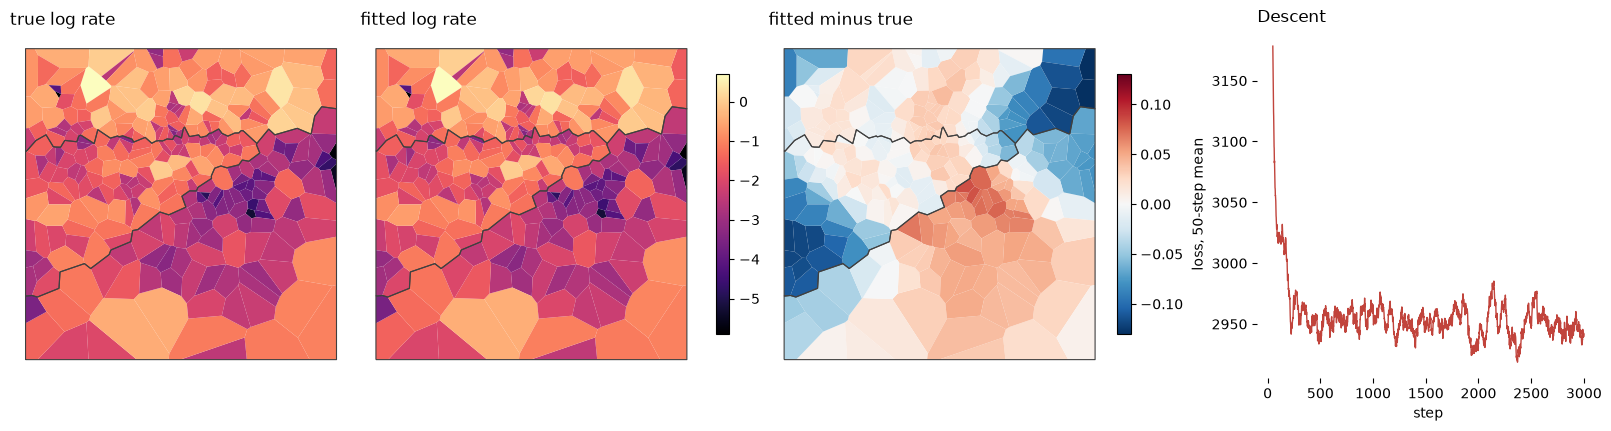

,value
wall clock (s),53.93
non-finite losses,0.00
"loss, first 100",3098.36
"loss, last 500",2950.62
"expected events, fitted",1503.64
events drawn,1502.00
"log rate, correlation with truth",1.00
"log rate, mean error",0.01
"log rate, sd of error",0.05


In [48]:
PANEL_YEAR = N_YEARS // 2

mean_1, variance_1 = ptgp.predict(svgp_1, features, result_1)
fitted_log_rate = np.log(weights) + mean_1 + variance_1 / 2.0
true_log_rate = np.log(true_rate)
trace_1 = pd.Series(result_1.result)

slice_of_year = slice(PANEL_YEAR * N_ATOMS, (PANEL_YEAR + 1) * N_ATOMS)
low, high = true_log_rate[slice_of_year].min(), true_log_rate[slice_of_year].max()

figure, axes = plt.subplots(1, 4, figsize=(16, 4.2))

drawn = plot_lattice(axes[0], true_log_rate[slice_of_year], title="true log rate", vmin=low, vmax=high)
plot_lattice(axes[1], fitted_log_rate[slice_of_year], title="fitted log rate", vmin=low, vmax=high)
figure.colorbar(drawn, ax=axes[:2], shrink=0.75, pad=0.02)

error = (fitted_log_rate - true_log_rate)[slice_of_year]
residual = plot_lattice(
    axes[2], error, title="fitted minus true", cmap="RdBu_r", vmin=-np.abs(error).max(), vmax=np.abs(error).max()
)
figure.colorbar(residual, ax=axes[2], shrink=0.75, pad=0.02)

axes[3].plot(trace_1.index, trace_1.rolling(50).mean(), color="#c1443c", linewidth=1.0)
axes[3].set_xlabel("step")
axes[3].set_ylabel("loss, 50-step mean")
axes[3].set_title("Descent", loc="left")

plt.show()

pd.Series(
    {
        "wall clock (s)": seconds_1,
        "non-finite losses": float(np.sum(~np.isfinite(result_1.result))),
        "loss, first 100": float(trace_1.iloc[:100].mean()),
        "loss, last 500": float(trace_1.iloc[-500:].mean()),
        "expected events, fitted": float(np.exp(fitted_log_rate).sum()),
        "events drawn": float(observations_1.n_units),
        "log rate, correlation with truth": float(np.corrcoef(fitted_log_rate, true_log_rate)[0, 1]),
        "log rate, mean error": float((fitted_log_rate - true_log_rate).mean()),
        "log rate, sd of error": float((fitted_log_rate - true_log_rate).std()),
    },
    name="value",
).to_frame().round(4)

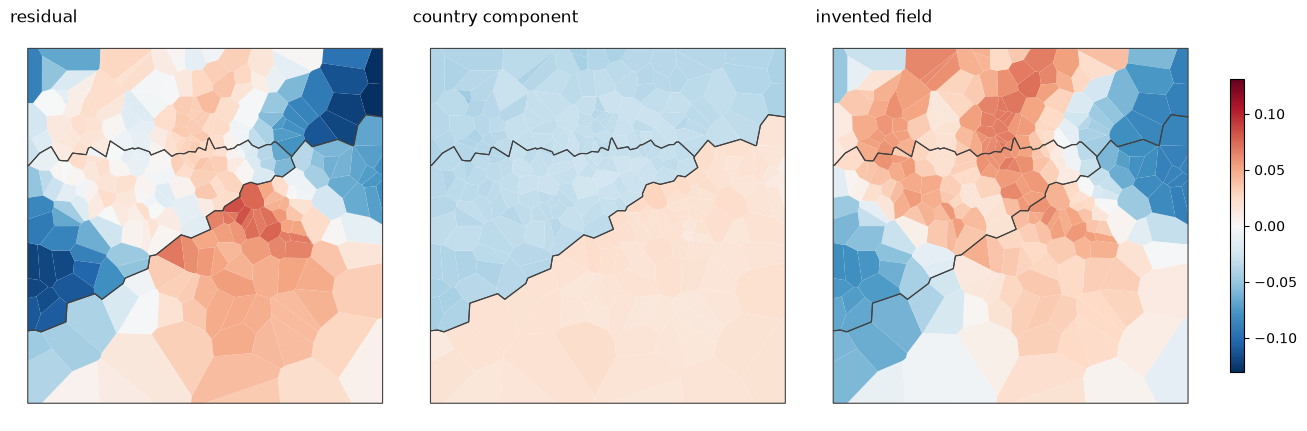

,value
"residual, sd",0.05
"country component, sd",0.03
"invented field, sd",0.05
"decomposition, largest gap",0.00
hydro amplitude fitted,0.09
coast amplitude fitted,0.08
"invented field, correlation with distance to river",-0.76
"invented field, correlation with log people",0.31


In [49]:
# The truth carries no field, so every departure is either the level split differently across the
# country offsets or a surface the model invented out of Poisson noise. Those two add up to the
# residual exactly, which makes the split a decomposition rather than a regression.
fitted_predictor = (
    float(trained_1["intercept"])
    + features[:, N_KERNEL_DIMS:-1] @ fitted_offsets
    + float(trained_1["population_exponent"]) * features[:, -1]
)
true_predictor = TRUE_INTERCEPT + country_part + population_part

country_component = fitted_predictor - true_predictor
field_component = mean_1 - fitted_predictor + variance_1 / 2.0
residual = fitted_log_rate - true_log_rate

figure, axes = plt.subplots(1, 3, figsize=(13, 4.2))
limit = np.abs(residual[slice_of_year]).max()

for axis, (title, values) in zip(
    axes,
    [
        ("residual", residual),
        ("country component", country_component),
        ("invented field", field_component),
    ],
    strict=True,
):
    drawn = plot_lattice(axis, values[slice_of_year], title=title, cmap="RdBu_r", vmin=-limit, vmax=limit)

figure.colorbar(drawn, ax=axes, shrink=0.75, pad=0.02)
plt.show()

pd.Series(
    {
        "residual, sd": float(residual.std()),
        "country component, sd": float(country_component.std()),
        "invented field, sd": float(field_component.std()),
        "decomposition, largest gap": float(np.abs(residual - country_component - field_component).max()),
        "hydro amplitude fitted": float(trained_1["hydro_amplitude"]),
        "coast amplitude fitted": float(trained_1["coast_amplitude"]),
        "invented field, correlation with distance to river": float(
            np.corrcoef(field_component, features[:, TO_RIVER])[0, 1]
        ),
        "invented field, correlation with log people": float(np.corrcoef(field_component, features[:, -1])[0, 1]),
    },
    name="value",
).to_frame().round(4)

## 2. Add the field

The field drawn from the prior at known amplitudes and lengthscales, counts still drawn at the atoms. This is where the inducing set is tested: too few points shows up here and nowhere else.

In [50]:
TRUE_HYDRO_AMPLITUDE = 0.5
TRUE_COAST_AMPLITUDE = 0.4
TRUE_HYDRO_LENGTHSCALES = (1.5, 2.0, 1.0)
TRUE_COAST_LENGTHSCALES = (1.2, 1.5)
FIELD_JITTER = 1e-8


def true_kernel():
    """The two surfaces the field is drawn from, at the lengthscales the fit has to find again."""
    return TRUE_HYDRO_AMPLITUDE**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array(TRUE_HYDRO_LENGTHSCALES, dtype=FLOATX),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + TRUE_COAST_AMPLITUDE**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array(TRUE_COAST_LENGTHSCALES, dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )


# Drawn exactly rather than through inducing points, so the fit is not handed back the same
# approximation it uses. At six thousand atom-years the dense factorization is affordable.
_rows = pt.matrix("rows")
covariance = pytensor.function([_rows], true_kernel()(_rows, _rows))(features)
covariance[np.diag_indices_from(covariance)] += FIELD_JITTER * np.trace(covariance) / len(covariance)
true_field = np.linalg.cholesky(covariance) @ rng.normal(size=len(covariance))

TRUE_INTERCEPT_2 = float(
    np.log(TARGET_EVENTS) - np.log((weights * np.exp(country_part + population_part + true_field)).sum())
)
true_rate_2 = weights * np.exp(TRUE_INTERCEPT_2 + country_part + population_part + true_field)
counts_2 = rng.poisson(true_rate_2)
observations_2 = events_at_cells(np.repeat(all_cells, counts_2))

pd.Series(
    {
        "true intercept": TRUE_INTERCEPT_2,
        "field, sd": float(true_field.std()),
        "field, smallest": float(true_field.min()),
        "field, largest": float(true_field.max()),
        "events drawn": float(observations_2.n_units),
        "atom-years with an event": float((counts_2 > 0).mean()),
        "field swing against the country spread": float(
            true_field.std() / TRUE_COUNTRY_OFFSETS.std()
        ),
    },
    name="value",
).to_frame().round(4)

,value
true intercept,-8.73
"field, sd",0.56
"field, smallest",-1.66
"field, largest",1.36
events drawn,1513.00
atom-years with an event,0.19
field swing against the country spread,0.81


In [51]:
started = time.perf_counter()
svgp_2, result_2 = fit_minibatch(
    features,
    observations_2,
    weights,
    inducing,
    mode=COMPILE_MODE,
    n_steps=ADAM_STEPS,
    n_windows=256,
    batch_size=2000,
    optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=8e-3),
    model_fn=build_model_2,
    covariate_bounds=COVARIATE_BOUNDS,
    temporal_bounds=TEMPORAL_BOUNDS,
)
seconds_2 = time.perf_counter() - started
trained_2 = result_2.params

fitted_offsets_2 = np.asarray(trained_2["country_offsets"])
recovery_2 = pd.DataFrame(
    {
        "true": [
            TRUE_INTERCEPT_2 + TRUE_COUNTRY_OFFSETS.mean(),
            *(TRUE_COUNTRY_OFFSETS - TRUE_COUNTRY_OFFSETS.mean()),
            TRUE_POPULATION_EXPONENT,
            TRUE_HYDRO_AMPLITUDE,
            TRUE_COAST_AMPLITUDE,
            *TRUE_HYDRO_LENGTHSCALES,
            *TRUE_COAST_LENGTHSCALES,
        ],
        "fitted": [
            float(trained_2["intercept"]) + fitted_offsets_2.mean(),
            *(fitted_offsets_2 - fitted_offsets_2.mean()),
            float(trained_2["population_exponent"]),
            float(trained_2["hydro_amplitude"]),
            float(trained_2["coast_amplitude"]),
            float(trained_2["hydro_lengthscale_to_river"]),
            float(trained_2["hydro_lengthscale_river_flow"]),
            float(trained_2["hydro_lengthscale_year"]),
            float(trained_2["coast_lengthscale_to_coast"]),
            float(trained_2["coast_lengthscale_year"]),
        ],
    },
    index=[
        "level",
        *(f"country {index} contrast" for index in range(N_COUNTRIES)),
        "population exponent",
        "hydro amplitude",
        "coast amplitude",
        "hydro ls, distance to river",
        "hydro ls, discharge",
        "hydro ls, time",
        "coast ls, distance to coast",
        "coast ls, time",
    ],
)
recovery_2["error"] = recovery_2["fitted"] - recovery_2["true"]
recovery_2.round(3)

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

,true,fitted,error
level,-8.66,-8.66,0.00
country 0 contrast,-0.87,-0.85,0.02
country 1 contrast,0.03,0.04,0.01
country 2 contrast,0.83,0.81,-0.03
population exponent,0.60,0.59,-0.01
hydro amplitude,0.50,0.36,-0.14
coast amplitude,0.40,0.33,-0.07
"hydro ls, distance to river",1.50,2.10,0.60
"hydro ls, discharge",2.00,1.92,-0.08
"hydro ls, time",1.00,1.58,0.58


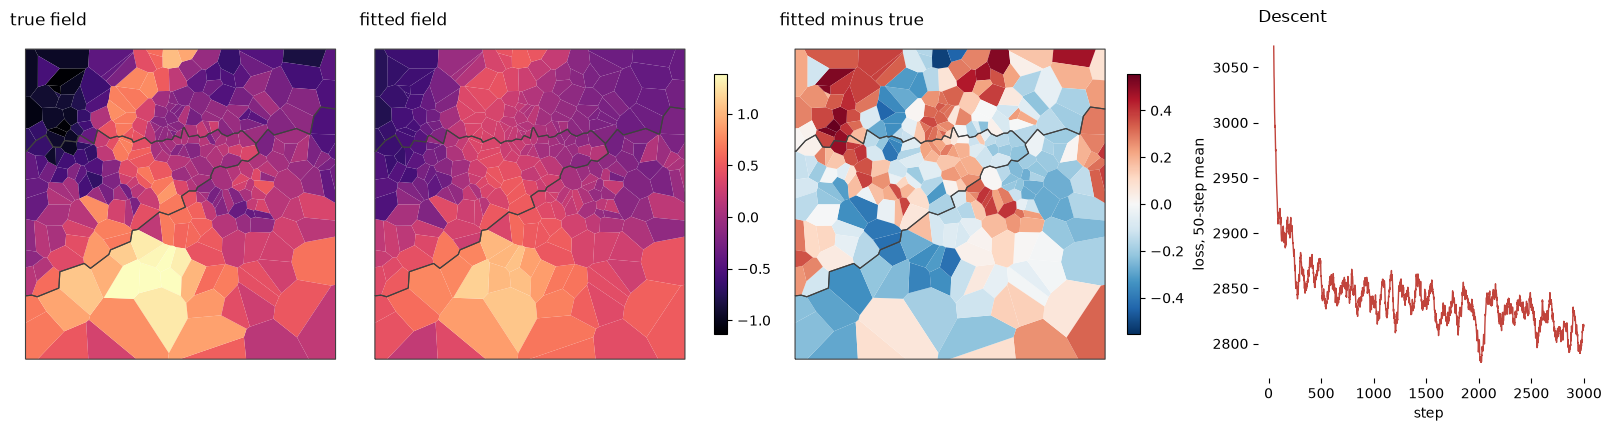

,value
wall clock (s),46.60
non-finite losses,0.00
"expected events, fitted",1513.31
events drawn,1513.00
"field, correlation with truth",0.90
"field, sd of truth",0.56
"field, sd of fit",0.45
"field, sd of the gap",0.25
"log rate, correlation with truth",0.98
"log rate, sd of error",0.25


In [52]:
mean_2, variance_2 = ptgp.predict(svgp_2, features, result_2)
fitted_log_rate_2 = np.log(weights) + mean_2 + variance_2 / 2.0
true_log_rate_2 = np.log(true_rate_2)

# The field on its own, with the linear predictor taken back off, so the surface is compared rather
# than the level it sits on. Both are centred: only the shape is identified against the intercept.
fitted_field = (
    mean_2
    - float(trained_2["intercept"])
    - features[:, N_KERNEL_DIMS:-1] @ fitted_offsets_2
    - float(trained_2["population_exponent"]) * features[:, -1]
)
centered_true, centered_fitted = true_field - true_field.mean(), fitted_field - fitted_field.mean()
trace_2 = pd.Series(result_2.result)

figure, axes = plt.subplots(1, 4, figsize=(16, 4.2))
low, high = centered_true[slice_of_year].min(), centered_true[slice_of_year].max()

drawn = plot_lattice(axes[0], centered_true[slice_of_year], title="true field", vmin=low, vmax=high)
plot_lattice(axes[1], centered_fitted[slice_of_year], title="fitted field", vmin=low, vmax=high)
figure.colorbar(drawn, ax=axes[:2], shrink=0.75, pad=0.02)

gap = (centered_fitted - centered_true)[slice_of_year]
missed = plot_lattice(
    axes[2], gap, title="fitted minus true", cmap="RdBu_r", vmin=-np.abs(gap).max(), vmax=np.abs(gap).max()
)
figure.colorbar(missed, ax=axes[2], shrink=0.75, pad=0.02)

axes[3].plot(trace_2.index, trace_2.rolling(50).mean(), color="#c1443c", linewidth=1.0)
axes[3].set_xlabel("step")
axes[3].set_ylabel("loss, 50-step mean")
axes[3].set_title("Descent", loc="left")

plt.show()

pd.Series(
    {
        "wall clock (s)": seconds_2,
        "non-finite losses": float(np.sum(~np.isfinite(result_2.result))),
        "expected events, fitted": float(np.exp(fitted_log_rate_2).sum()),
        "events drawn": float(observations_2.n_units),
        "field, correlation with truth": float(np.corrcoef(centered_fitted, centered_true)[0, 1]),
        "field, sd of truth": float(centered_true.std()),
        "field, sd of fit": float(centered_fitted.std()),
        "field, sd of the gap": float((centered_fitted - centered_true).std()),
        "log rate, correlation with truth": float(np.corrcoef(fitted_log_rate_2, true_log_rate_2)[0, 1]),
        "log rate, sd of error": float((fitted_log_rate_2 - true_log_rate_2).std()),
    },
    name="value",
).to_frame().round(4)

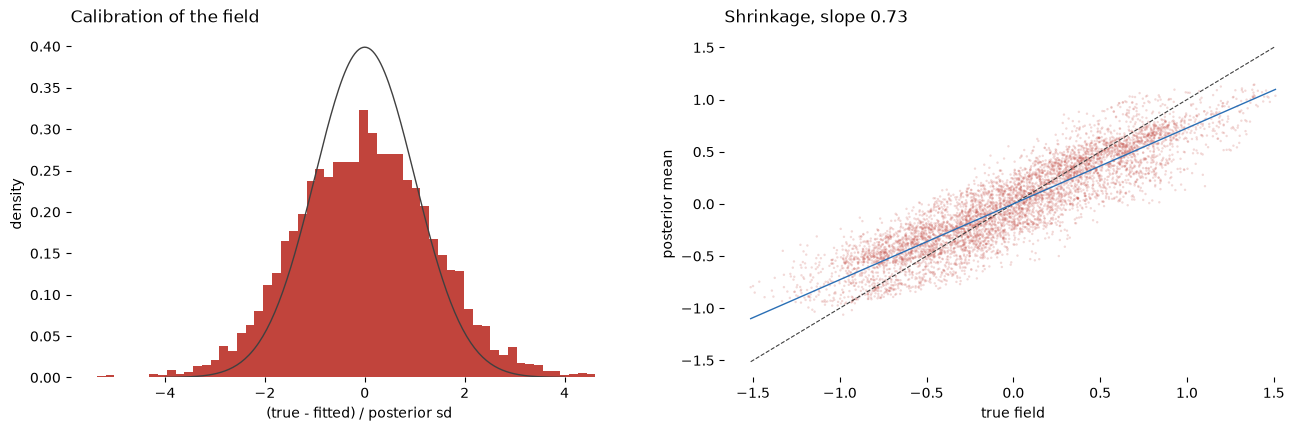

,value
variance of the truth,0.31
variance of the posterior mean,0.20
mean posterior variance,0.03
"mean plus variance, against the truth",0.76
"standardized error, sd",1.37
"standardized error, share beyond two sd",0.13
"regression of the mean on the truth, slope",0.73


In [60]:
# A posterior mean is not a draw, and cannot match one: the mean is shrunk toward the prior by
# whatever the data does not pin down. For a Gaussian posterior the shrinkage is exact --
# var(truth) = var(posterior mean) + mean(posterior variance) -- so the check is whether the
# missing variance is accounted for, and whether the truth sits inside the stated uncertainty.
posterior_sd = np.sqrt(variance_2)
standardized_error = (centered_true - centered_fitted) / posterior_sd

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 4.2))

left.hist(standardized_error, bins=60, color="#c1443c", density=True)
grid = np.linspace(-4.0, 4.0, 201)
left.plot(grid, np.exp(-0.5 * grid**2) / np.sqrt(2 * np.pi), color="0.25", linewidth=1.0)
left.set_xlabel("(true - fitted) / posterior sd")
left.set_ylabel("density")
left.set_title("Calibration of the field", loc="left")

right.scatter(centered_true, centered_fitted, s=3, alpha=0.2, color="#c1443c", edgecolor="none")
span = [centered_true.min(), centered_true.max()]
right.plot(span, span, color="0.25", linewidth=0.8, linestyle="--")
slope = float(np.polyfit(centered_true, centered_fitted, 1)[0])
right.plot(span, [slope * value for value in span], color="#2a6fb5", linewidth=1.0)
right.set_xlabel("true field")
right.set_ylabel("posterior mean")
right.set_title(f"Shrinkage, slope {slope:.2f}", loc="left")

plt.show()

pd.Series(
    {
        "variance of the truth": float(centered_true.var()),
        "variance of the posterior mean": float(centered_fitted.var()),
        "mean posterior variance": float(variance_2.mean()),
        "mean plus variance, against the truth": float(
            (centered_fitted.var() + variance_2.mean()) / centered_true.var()
        ),
        "standardized error, sd": float(standardized_error.std()),
        "standardized error, share beyond two sd": float((np.abs(standardized_error) > 2).mean()),
        "regression of the mean on the truth, slope": slope,
    },
    name="value",
).to_frame().round(4)

In [53]:
INDUCING_SWEEP = (100, 200, 400, 800)

TRUE_LENGTHSCALES = {
    "hydro ls, distance to river": (TRUE_HYDRO_LENGTHSCALES[0], "hydro_lengthscale_to_river"),
    "hydro ls, discharge": (TRUE_HYDRO_LENGTHSCALES[1], "hydro_lengthscale_river_flow"),
    "hydro ls, time": (TRUE_HYDRO_LENGTHSCALES[2], "hydro_lengthscale_year"),
    "coast ls, distance to coast": (TRUE_COAST_LENGTHSCALES[0], "coast_lengthscale_to_coast"),
    "coast ls, time": (TRUE_COAST_LENGTHSCALES[1], "coast_lengthscale_year"),
}

# Same data, same truth, same optimizer: only the inducing set moves. If the long bias is the
# sparse approximation smoothing what it cannot resolve, it shrinks along this axis; if it is the
# lengthscale prior pulling, it does not.
sweep = {}
for count in INDUCING_SWEEP:
    selection = select_inducing(features, count, prior_kernel())
    health = compute_inducing_diagnostics(prior_kernel(), features, selection)

    _, swept = fit_minibatch(
        features,
        observations_2,
        weights,
        selection[:, :N_KERNEL_DIMS],
        mode=COMPILE_MODE,
        n_steps=ADAM_STEPS,
        n_windows=256,
        batch_size=2000,
        optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=8e-3),
        model_fn=build_model_2,
        covariate_bounds=COVARIATE_BOUNDS,
        temporal_bounds=TEMPORAL_BOUNDS,
    )

    sweep[count] = {
        "variance explained (%)": 100 * (1 - health.nystrom_residual / health.total_variance),
        "hydro amplitude": float(swept.params["hydro_amplitude"]),
        "coast amplitude": float(swept.params["coast_amplitude"]),
        **{name: float(swept.params[key]) for name, (_, key) in TRUE_LENGTHSCALES.items()},
    }

sweep_frame = pd.DataFrame(sweep).T.rename_axis("inducing points")
sweep_frame.round(3)

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

,variance explained (%),hydro amplitude,coast amplitude,"hydro ls, distance to river","hydro ls, discharge","hydro ls, time","coast ls, distance to coast","coast ls, time"
inducing points,,,,,,,,
100,97.10,0.36,0.32,2.42,1.81,1.66,1.61,2.06
200,98.84,0.37,0.32,2.15,1.69,1.53,1.28,1.86
400,99.52,0.39,0.33,2.13,1.81,1.50,1.44,1.83
800,99.83,0.39,0.32,2.05,1.74,1.43,1.34,1.69


## 3. Add the window operator

The same truth as section 2, observed through unions of units rather than at the atoms. The comparison against section 2 is the price of the aggregation.

## 4. The ceiling

The real event count and the real footprints, scored with the diagnostics from notebook 02. Whatever this reaches is the most the current setup can reach.

In [56]:
centroids = np.column_stack([atom_x, atom_y])
neighbor_order = np.argsort(((centroids[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=-1), axis=1)
event_cells_2 = np.repeat(all_cells, counts_2)


def units_reached(cell, size):
    """The units an event in ``cell`` is reported through: the ``size`` nearest, itself included."""
    return neighbor_order[cell % N_ATOMS, :size]


def windows_around(cells, size):
    """One row per event, covering the ``size`` units nearest the one it happened in, that year."""
    atoms_of, years_of = cells % N_ATOMS, cells // N_ATOMS
    reached = neighbor_order[atoms_of, :size] + years_of[:, None] * N_ATOMS
    columns = reached.ravel()

    return Aggregation(
        units=tuple(str(row) for row in range(len(cells))),
        rows=np.repeat(np.arange(len(cells)), size),
        columns=columns,
        weights=weights[columns],
        n_cells=n_cells,
    )

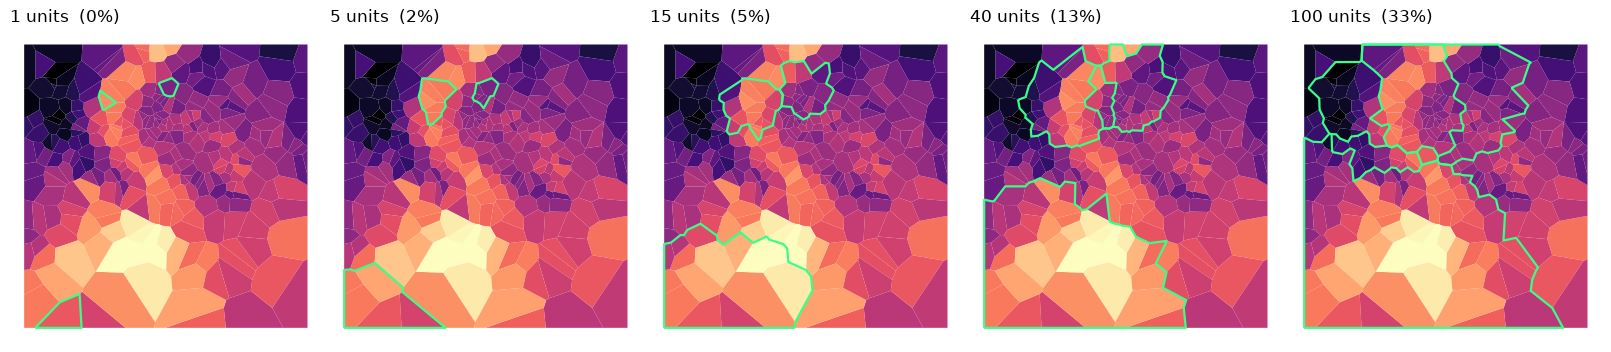

In [57]:
FOOTPRINT_SWEEP = (1, 5, 15, 40, 100)
SHOWN_EVENTS = 3

# What the likelihood is told, at each width: the event happened somewhere inside the outline, and
# nothing narrows it further.
shown = rng.choice(len(event_cells_2), size=SHOWN_EVENTS, replace=False)

figure, axes = plt.subplots(1, len(FOOTPRINT_SWEEP), figsize=(16, 3.6))

for axis, size in zip(axes, FOOTPRINT_SWEEP, strict=True):
    plot_lattice(axis, true_field[slice_of_year], title=f"{size} units  ({size / N_ATOMS:.0%})", borders=False)
    for event in shown:
        footprint = atom_cells.iloc[units_reached(event_cells_2[event], size)].union_all()
        gpd.GeoSeries([footprint]).boundary.plot(ax=axis, color="#39ff88", linewidth=1.6)

plt.show()

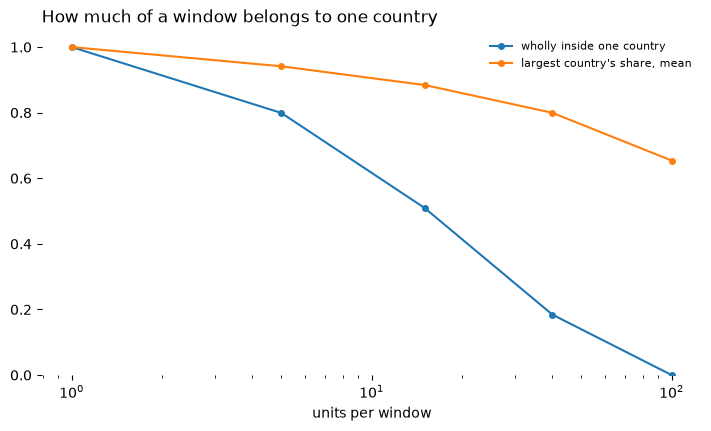

,windows inside one country,"largest country's share, mean"
units per window,,
1,1.00,1.00
5,0.80,0.94
15,0.51,0.88
40,0.18,0.80
100,0.00,0.65


In [66]:
# A country indicator is a covariate like any other, and a window that crosses a border reports a
# blend of countries rather than one. If the offsets fail because the design is smeared rather than
# because the aggregates are thin, the share of windows that stay inside one country should fall
# alongside them.
purity = {}
for size in FOOTPRINT_SWEEP:
    operator = windows_around(event_cells_2, size).matrix
    exposure = operator @ np.ones(n_cells)
    shares = np.column_stack(
        [(operator @ features[:, N_KERNEL_DIMS + country]) / exposure for country in range(N_COUNTRIES)]
    )
    purity[size] = {
        "windows inside one country": float((shares.max(axis=1) > 0.999).mean()),
        "largest country's share, mean": float(shares.max(axis=1).mean()),
    }

figure, ax = plt.subplots(figsize=(7, 4.2))
purity_frame = pd.DataFrame(purity).T

ax.plot(purity_frame.index, purity_frame["windows inside one country"], marker="o", markersize=4, label="wholly inside one country")
ax.plot(purity_frame.index, purity_frame["largest country's share, mean"], marker="o", markersize=4, label="largest country's share, mean")
ax.set_xscale("log")
ax.set_xlabel("units per window")
ax.set_ylim(0.0, 1.05)
ax.set_title("How much of a window belongs to one country", loc="left")
ax.legend(frameon=False, fontsize=8)

plt.show()

purity_frame.rename_axis("units per window").round(3)

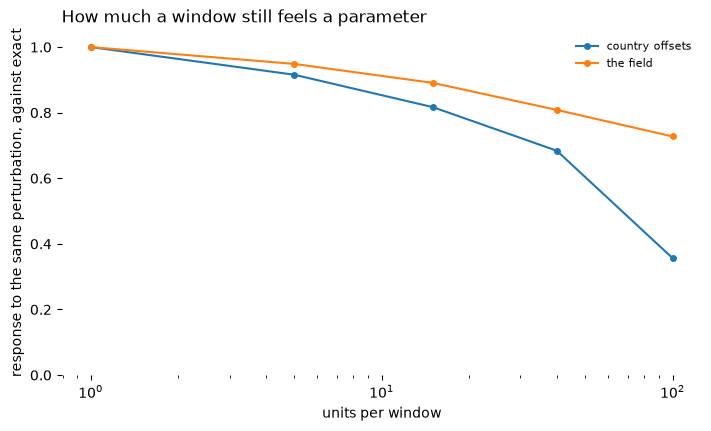

,country offsets,the field
units per window,,
1,0.21,0.31
5,0.19,0.29
15,0.17,0.28
40,0.14,0.25
100,0.07,0.22


In [67]:
PERTURBATION = 0.3

# The objective evaluates every covariate at its own atom and only then aggregates, so nothing is
# averaged before it reaches the model. What a window still constrains is one scalar per window, so
# the question is how far that scalar moves when a parameter does. Perturbing at the truth and
# measuring the response needs no fit: a response that decays with the footprint is the likelihood
# going flat, which is identification rather than any fault in the objective.
contrast_shift = np.array([PERTURBATION, -PERTURBATION, 0.0])
baseline = TRUE_INTERCEPT_2 + country_part + population_part + true_field
shifted_countries = baseline + features[:, N_KERNEL_DIMS:-1] @ contrast_shift
shifted_field = baseline + PERTURBATION * (true_field - true_field.mean()) / true_field.std()


def window_log_totals(operator, log_rate):
    """Log of each window's expected count, the way the objective forms it."""
    return np.log(operator @ np.exp(log_rate))


response = {}
for size in FOOTPRINT_SWEEP:
    operator = windows_around(event_cells_2, size).matrix
    at_truth = window_log_totals(operator, baseline)
    response[size] = {
        "country offsets": float(np.std(window_log_totals(operator, shifted_countries) - at_truth)),
        "the field": float(np.std(window_log_totals(operator, shifted_field) - at_truth)),
    }

response_frame = pd.DataFrame(response).T

figure, ax = plt.subplots(figsize=(7, 4.2))
for name in response_frame:
    ax.plot(response_frame.index, response_frame[name] / response_frame[name].iloc[0], marker="o", markersize=4, label=name)
ax.set_xscale("log")
ax.set_xlabel("units per window")
ax.set_ylabel("response to the same perturbation, against exact")
ax.set_ylim(0.0, 1.05)
ax.set_title("How much a window still feels a parameter", loc="left")
ax.legend(frameon=False, fontsize=8)

plt.show()

response_frame.rename_axis("units per window").round(4)

In [65]:
# Held fixed across the sweep rather than left at the section 2 value. The batch sampler draws its
# quadrature points without replacement, so a wide footprint times many windows asks for more
# distinct cells than the lattice has; and letting the count vary with the footprint would change
# the gradient noise alongside the thing being measured.
SWEEP_WINDOWS = 32

true_contrasts = TRUE_COUNTRY_OFFSETS - TRUE_COUNTRY_OFFSETS.mean()

# The events are the same draw throughout: only how coarsely they are reported changes, so the
# curve is the price of the aggregation and nothing else. The offsets are carried alongside the
# field because they are the low-dimensional half of the transfer: if they hold where the surface
# collapses, the aggregates support exactly as many parameters as they carry and no more.
aggregation_sweep = {}
swept_fields = {}
for size in FOOTPRINT_SWEEP:
    swept_gp, swept = fit_minibatch(
        features,
        windows_around(event_cells_2, size),
        weights,
        inducing,
        mode=COMPILE_MODE,
        n_steps=ADAM_STEPS,
        n_windows=SWEEP_WINDOWS,
        batch_size=2000,
        optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=8e-3),
        model_fn=build_model_2,
        covariate_bounds=COVARIATE_BOUNDS,
        temporal_bounds=TEMPORAL_BOUNDS,
    )
    swept_mean, _ = ptgp.predict(swept_gp, features, swept)
    swept_offsets = np.asarray(swept.params["country_offsets"])
    swept_field = (
        swept_mean
        - float(swept.params["intercept"])
        - features[:, N_KERNEL_DIMS:-1] @ swept_offsets
        - float(swept.params["population_exponent"]) * features[:, -1]
    )
    swept_fields[size] = swept_field - swept_field.mean()
    swept_contrasts = swept_offsets - swept_offsets.mean()

    aggregation_sweep[size] = {
        "share of the region a window covers": size / N_ATOMS,
        "field, correlation with truth": float(np.corrcoef(swept_fields[size], centered_true)[0, 1]),
        "field, sd of fit": float(swept_fields[size].std()),
        "level, error": float(swept.params["intercept"] + swept_offsets.mean())
        - (TRUE_INTERCEPT_2 + TRUE_COUNTRY_OFFSETS.mean()),
        "country contrasts, largest error": float(np.abs(swept_contrasts - true_contrasts).max()),
        **{f"country {index} contrast": float(value) for index, value in enumerate(swept_contrasts)},
        "population exponent": float(swept.params["population_exponent"]),
        "hydro amplitude": float(swept.params["hydro_amplitude"]),
        "coast amplitude": float(swept.params["coast_amplitude"]),
        **{name: float(swept.params[key]) for name, (_, key) in TRUE_LENGTHSCALES.items()},
    }

aggregation_frame = pd.DataFrame(aggregation_sweep).T.rename_axis("units per window")
aggregation_frame.round(3)

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

,share of the region a window covers,"field, correlation with truth","field, sd of fit","level, error","country contrasts, largest error",country 0 contrast,country 1 contrast,country 2 contrast,population exponent,hydro amplitude,coast amplitude,"hydro ls, distance to river","hydro ls, discharge","hydro ls, time","coast ls, distance to coast","coast ls, time"
units per window,,,,,,,,,,,,,,,,
1,0.00,0.90,0.42,0.04,0.08,-0.79,0.03,0.76,0.59,0.30,0.31,2.12,1.96,1.53,1.31,1.76
5,0.02,0.84,0.43,-0.09,0.14,-0.74,0.05,0.70,0.48,0.29,0.35,1.90,2.02,1.28,1.10,1.94
15,0.05,0.89,0.43,-0.29,0.33,-0.55,-0.30,0.85,0.89,0.34,0.31,2.13,1.73,1.50,1.22,1.59
40,0.13,0.58,0.64,-0.72,0.57,-0.30,-0.35,0.64,0.91,0.24,0.54,2.19,2.12,1.23,0.84,2.60
100,0.33,0.29,1.35,-2.16,1.90,-1.98,1.93,0.05,0.93,0.31,0.79,2.58,1.86,1.83,0.99,4.50


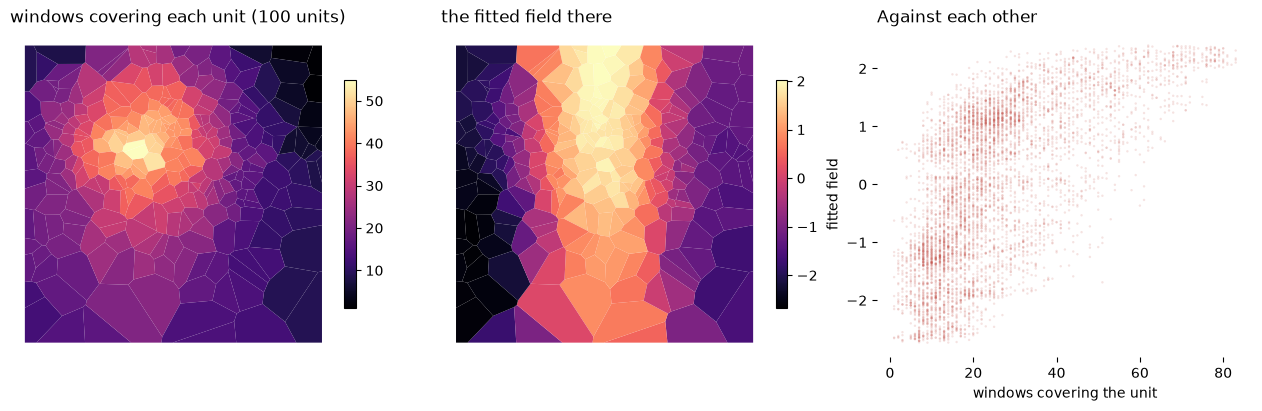

,"fitted field, correlation with coverage","fitted field, correlation with truth","coverage, largest over smallest"
units per window,,,
1,0.21,0.90,7.00
5,0.38,0.84,17.00
15,0.39,0.89,30.00
40,0.61,0.58,44.00
100,0.64,0.29,83.00


In [68]:
# Why the wide-window fit is extreme rather than flat. The window term is a log-sum-exp, so it
# reads a window's largest atom and barely notices the rest, while the region term fixes only the
# grand total. Mass is therefore worth most where it lands inside the most windows at once, and a
# k-nearest footprint reaches a central atom from far more directions than an edge one. If that is
# what the fit is drawing, the collapsed field is a map of coverage rather than of the surface.
coverage = {}
for size in FOOTPRINT_SWEEP:
    operator = windows_around(event_cells_2, size).matrix
    coverage[size] = np.asarray((operator != 0).sum(axis=0)).ravel()

widest = FOOTPRINT_SWEEP[-1]

figure, axes = plt.subplots(1, 3, figsize=(13, 4.0))

drawn = plot_lattice(axes[0], coverage[widest][slice_of_year], title=f"windows covering each unit ({widest} units)", borders=False)
figure.colorbar(drawn, ax=axes[0], shrink=0.7, pad=0.02)

collapsed = plot_lattice(axes[1], swept_fields[widest][slice_of_year], title="the fitted field there", borders=False)
figure.colorbar(collapsed, ax=axes[1], shrink=0.7, pad=0.02)

axes[2].scatter(coverage[widest], swept_fields[widest], s=3, alpha=0.15, color="#c1443c", edgecolor="none")
axes[2].set_xlabel("windows covering the unit")
axes[2].set_ylabel("fitted field")
axes[2].set_title("Against each other", loc="left")

plt.show()

pd.DataFrame(
    {
        "fitted field, correlation with coverage": {
            size: float(np.corrcoef(swept_fields[size], coverage[size])[0, 1]) for size in FOOTPRINT_SWEEP
        },
        "fitted field, correlation with truth": {
            size: aggregation_sweep[size]["field, correlation with truth"] for size in FOOTPRINT_SWEEP
        },
        "coverage, largest over smallest": {
            size: float(coverage[size].max() / max(coverage[size].min(), 1)) for size in FOOTPRINT_SWEEP
        },
    }
).rename_axis("units per window").round(3)

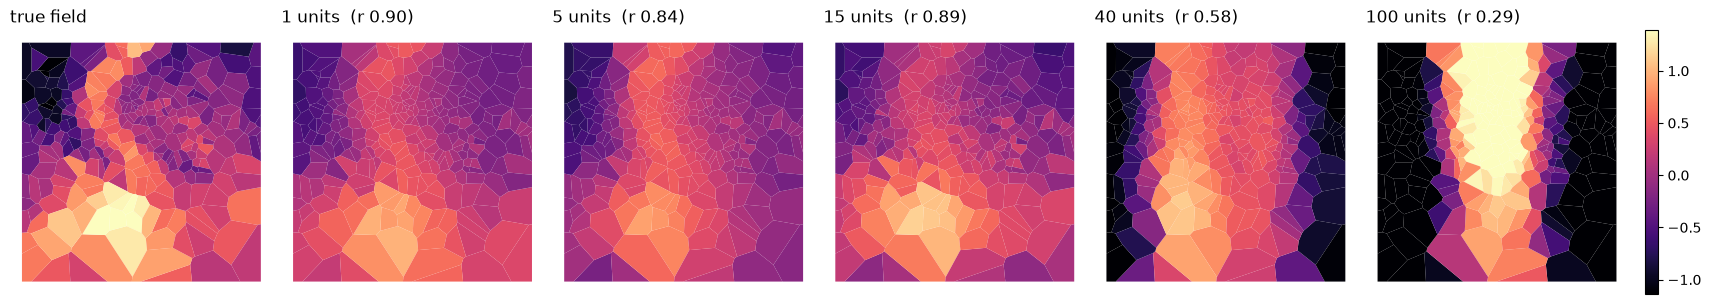

In [59]:
# Every panel on the truth's own colour scale, so a fit that inflates its field reads as saturation
# rather than being rescaled into looking reasonable.
low, high = centered_true[slice_of_year].min(), centered_true[slice_of_year].max()

figure, axes = plt.subplots(1, len(FOOTPRINT_SWEEP) + 1, figsize=(17, 3.6))

drawn = plot_lattice(axes[0], centered_true[slice_of_year], title="true field", vmin=low, vmax=high, borders=False)
for axis, size in zip(axes[1:], FOOTPRINT_SWEEP, strict=True):
    correlation = aggregation_sweep[size]["field, correlation with truth"]
    plot_lattice(
        axis,
        swept_fields[size][slice_of_year],
        title=f"{size} units  (r {correlation:.2f})",
        vmin=low,
        vmax=high,
        borders=False,
    )

figure.colorbar(drawn, ax=axes, shrink=0.75, pad=0.01)
plt.show()

### Mixed reporting widths

Real reporting is not one width. Holding the events fixed and varying only the share reported narrowly asks whether a well-located minority carries a vague majority, or drowns in it.

In [61]:
NARROW, WIDE = 5, 100
MIX_SWEEP = (0.0, 0.1, 0.25, 0.5, 0.75, 1.0)


def mixed_windows(cells, sizes):
    """One row per event, each covering as many units as its own entry in ``sizes``."""
    atoms_of, years_of = cells % N_ATOMS, cells // N_ATOMS
    reached = [
        neighbor_order[atom, :size] + year * N_ATOMS
        for atom, year, size in zip(atoms_of, years_of, sizes, strict=True)
    ]
    columns = np.concatenate(reached)

    return Aggregation(
        units=tuple(str(row) for row in range(len(cells))),
        rows=np.repeat(np.arange(len(cells)), sizes),
        columns=columns,
        weights=weights[columns],
        n_cells=n_cells,
    )


mixture = {}
mixed_fields = {}
for share in MIX_SWEEP:
    sizes = np.where(rng.random(len(event_cells_2)) < share, NARROW, WIDE)

    mixed_gp, mixed = fit_minibatch(
        features,
        mixed_windows(event_cells_2, sizes),
        weights,
        inducing,
        mode=COMPILE_MODE,
        n_steps=ADAM_STEPS,
        n_windows=SWEEP_WINDOWS,
        batch_size=2000,
        optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=8e-3),
        model_fn=build_model_2,
        covariate_bounds=COVARIATE_BOUNDS,
        temporal_bounds=TEMPORAL_BOUNDS,
    )
    mixed_mean, _ = ptgp.predict(mixed_gp, features, mixed)
    mixed_offsets = np.asarray(mixed.params["country_offsets"])
    mixed_field = (
        mixed_mean
        - float(mixed.params["intercept"])
        - features[:, N_KERNEL_DIMS:-1] @ mixed_offsets
        - float(mixed.params["population_exponent"]) * features[:, -1]
    )
    mixed_fields[share] = mixed_field - mixed_field.mean()

    mixture[share] = {
        "events reported narrowly": float((sizes == NARROW).sum()),
        "field, correlation with truth": float(np.corrcoef(mixed_fields[share], centered_true)[0, 1]),
        "field, sd of fit": float(mixed_fields[share].std()),
        "population exponent": float(mixed.params["population_exponent"]),
        "hydro amplitude": float(mixed.params["hydro_amplitude"]),
        "coast amplitude": float(mixed.params["coast_amplitude"]),
    }

mixture_frame = pd.DataFrame(mixture).T.rename_axis("share reported narrowly")
mixture_frame.round(3)

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

adam:   0%|          | 0/3000 [00:00<?, ?it/s]

,events reported narrowly,"field, correlation with truth","field, sd of fit",population exponent,hydro amplitude,coast amplitude
share reported narrowly,,,,,,
0.00,0.00,0.29,1.35,0.93,0.31,0.79
0.10,142.00,0.45,0.85,0.91,0.22,0.56
0.25,388.00,0.54,0.63,0.85,0.24,0.43
0.50,764.00,0.67,0.46,0.72,0.22,0.37
0.75,1142.00,0.79,0.43,0.58,0.26,0.34
1.00,1513.00,0.84,0.43,0.48,0.29,0.35


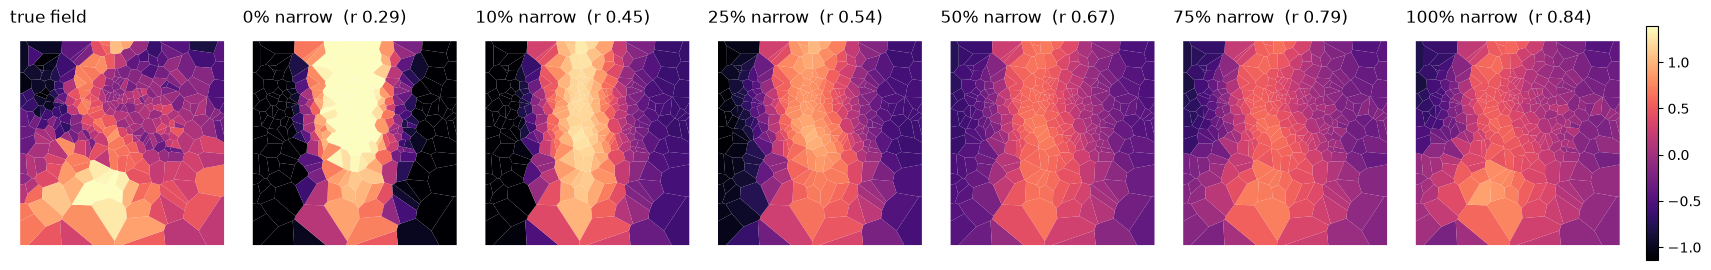

In [62]:
figure, axes = plt.subplots(1, len(MIX_SWEEP) + 1, figsize=(17, 3.2))

drawn = plot_lattice(axes[0], centered_true[slice_of_year], title="true field", vmin=low, vmax=high, borders=False)
for axis, share in zip(axes[1:], MIX_SWEEP, strict=True):
    correlation = mixture[share]["field, correlation with truth"]
    plot_lattice(
        axis,
        mixed_fields[share][slice_of_year],
        title=f"{share:.0%} narrow  (r {correlation:.2f})",
        vmin=low,
        vmax=high,
        borders=False,
    )

figure.colorbar(drawn, ax=axes, shrink=0.75, pad=0.01)
plt.show()

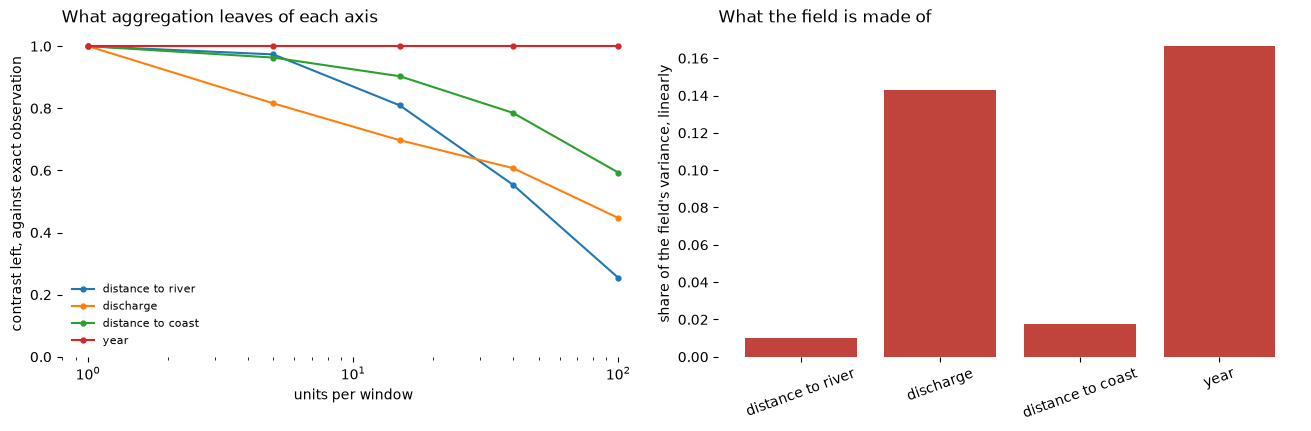

,distance to river,discharge,distance to coast,year
units per window,,,,
1,1.00,1.00,1.00,1.00
5,0.97,0.82,0.96,1.00
15,0.81,0.70,0.90,1.00
40,0.55,0.61,0.79,1.00
100,0.25,0.45,0.59,1.00


In [64]:
KERNEL_AXES = {"distance to river": TO_RIVER, "discharge": RIVER_FLOW, "distance to coast": TO_COAST, "year": YEAR}

# What a window can still say about a covariate is the contrast between windows, not the contrast
# inside one. Averaging a covariate over each window and comparing the spread of those averages
# against the same events observed exactly is an upper bound on what any fit could learn from that
# axis. Events are not a uniform sample of the lattice, so the exact case is the baseline rather
# than the lattice-wide variance.
window_contrast = {}
for size in FOOTPRINT_SWEEP:
    operator = windows_around(event_cells_2, size).matrix
    exposure = operator @ np.ones(n_cells)
    window_contrast[size] = {
        name: float(((operator @ features[:, column]) / exposure).var()) for name, column in KERNEL_AXES.items()
    }

surviving = pd.DataFrame(window_contrast).T
surviving = surviving / surviving.loc[FOOTPRINT_SWEEP[0]]

# What the field is actually made of, so a lost axis can be weighed against how much it carried.
# A linear share understates a Matern surface, which bends; it ranks the axes rather than
# partitioning the variance.
composition = {
    name: float(np.corrcoef(centered_true, features[:, column])[0, 1] ** 2) for name, column in KERNEL_AXES.items()
}

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 4.2))

for name in KERNEL_AXES:
    left.plot(surviving.index, surviving[name], marker="o", markersize=3.5, label=name)
left.set_xscale("log")
left.set_xlabel("units per window")
left.set_ylabel("contrast left, against exact observation")
left.set_ylim(0.0, 1.05)
left.set_title("What aggregation leaves of each axis", loc="left")
left.legend(frameon=False, fontsize=8)

right.bar(list(composition), list(composition.values()), color="#c1443c")
right.set_ylabel("share of the field's variance, linearly")
right.set_title("What the field is made of", loc="left")
right.tick_params(axis="x", rotation=20)

plt.show()

surviving.rename_axis("units per window").round(3)